# Time-Series Clustering of Buffalo Lactation Curves

**Why a new notebook?** The previous `Clustering.ipynb` collapsed every animal/lactation into a few *scalar means* (mean milk, mean DIM, parity) and clustered those. That only reproduces "high / medium / low producer" bands and **discards the time dimension** entirely — which is the most informative part of your data.

**What the data really is.** Each lactation (`Animal_ID` x `parity`) is a short *time series*: `milk_kg` measured at several test-days across `DIM` (days in milk). That sequence is a **lactation curve**. ~247k lactations, median 7 test-days each, DIM 1-365.

**The right question** is not *how much* milk, but the **shape of the curve over time**: sharp early peak then steep decline vs. flat & persistent vs. slow-rising. For a heat-stress thesis this matters because heat stress flattens/depresses the curve, especially around peak.

We use two complementary, literature-standard time-series clustering strategies:

1. **Model-free shape clustering** - interpolate each curve onto a common DIM grid, then cluster the aligned curves (whole-shape clustering, no model assumed).
2. **Parametric curve-feature clustering** - fit **Wood's** incomplete-gamma curve `y = a * t^b * exp(-c*t)` to each lactation and cluster the *interpretable* shape parameters (peak yield, days-to-peak, persistency, 305-d yield). This is the standard approach in dairy science.

The original data files are only ever **read**, never modified.

In [49]:
import os
# Keep BLAS from oversubscribing cores (set before importing numpy).
N_JOBS = max(1, (os.cpu_count() or 2) - 1)
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ.setdefault(_v, str(min(N_JOBS, 8)))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from joblib import Parallel, delayed

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
print(f'Using up to {N_JOBS} cores')

Using up to 7 cores


In [50]:
# ---- Load (READ ONLY) ----
PATH = '../Thesis_Data/Final_Data/After_Processing.csv'
df = pd.read_csv(PATH, usecols=['Farm_Code', 'Animal_ID', 'parity', 'DIM', 'milk_kg'])
df = df.dropna(subset=['DIM', 'milk_kg'])
df = df[(df['milk_kg'] > 0) & (df['DIM'].between(1, 365))]

# A 'lactation' = one animal in one parity = one time series of milk over DIM.
df['lact_id'] = df['Animal_ID'].astype(str) + '_p' + df['parity'].astype(int).astype(str)
df = df.sort_values(['lact_id', 'DIM'])
print(f'{len(df):,} test-day records | {df.lact_id.nunique():,} lactations | {df.Animal_ID.nunique():,} animals')
df.head()

1,646,809 test-day records | 247,247 lactations | 91,221 animals


,Farm_Code,Animal_ID,parity,milk_kg,DIM,lact_id
361697,5700690,ES020904991568,1,6.800,26,ES020904991568_p1
361698,5700690,ES020904991568,1,9.200,60,ES020904991568_p1
361699,5700690,ES020904991568,1,7.800,92,ES020904991568_p1
361700,5700690,ES020904991568,1,6.100,125,ES020904991568_p1
361701,5700690,ES020904991568,1,1.900,159,ES020904991568_p1


## Raw data: milk_kg vs DIM (no clustering)

Before any modelling, just look at the data. Left: all 1.6M test-day records as a density (brighter = more records). Right: a few individual buffalo, each line is one animal's real test days over time = the lactation time series.

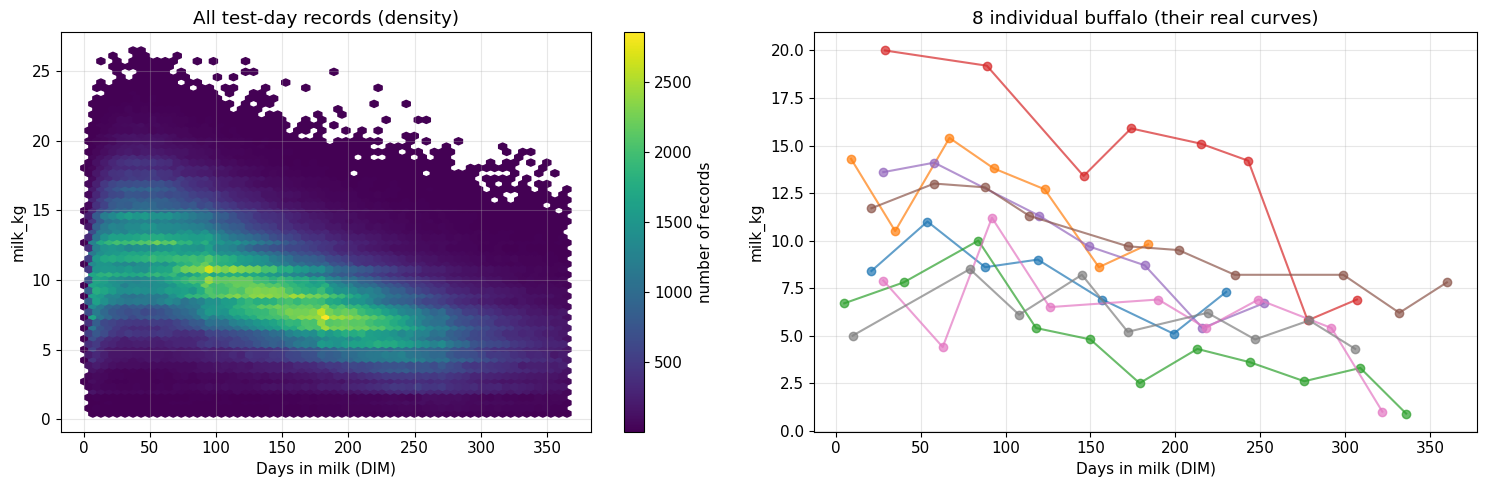

In [51]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Left: every test-day record as a 2-D density (1.6M points -> a scatter would be a blob)
hb = ax[0].hexbin(df['DIM'], df['milk_kg'], gridsize=60, cmap='viridis', mincnt=1)
ax[0].set(title='All test-day records (density)', xlabel='Days in milk (DIM)', ylabel='milk_kg')
fig.colorbar(hb, ax=ax[0], label='number of records')

# Right: a few individual buffalo, connected over DIM = the time series
counts = df.groupby('lact_id').size()
good = counts[counts >= 7].index
rng = np.random.default_rng(1)
for lid in rng.choice(good, 8, replace=False):
    g = df[df['lact_id'] == lid].sort_values('DIM')
    ax[1].plot(g['DIM'], g['milk_kg'], 'o-', alpha=.7)
ax[1].set(title='8 individual buffalo (their real curves)', xlabel='Days in milk (DIM)', ylabel='milk_kg')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Average curve, and how it changes with parity

Left: the overall average lactation curve (red) over the density of all records - peak around DIM 45, then steady decline. Right: the average curve split by parity (lactation number). First-lactation buffalo (parity 1) produce clearly less; parities 2+ are higher and bunched together. This is why each lactation is clustered separately.

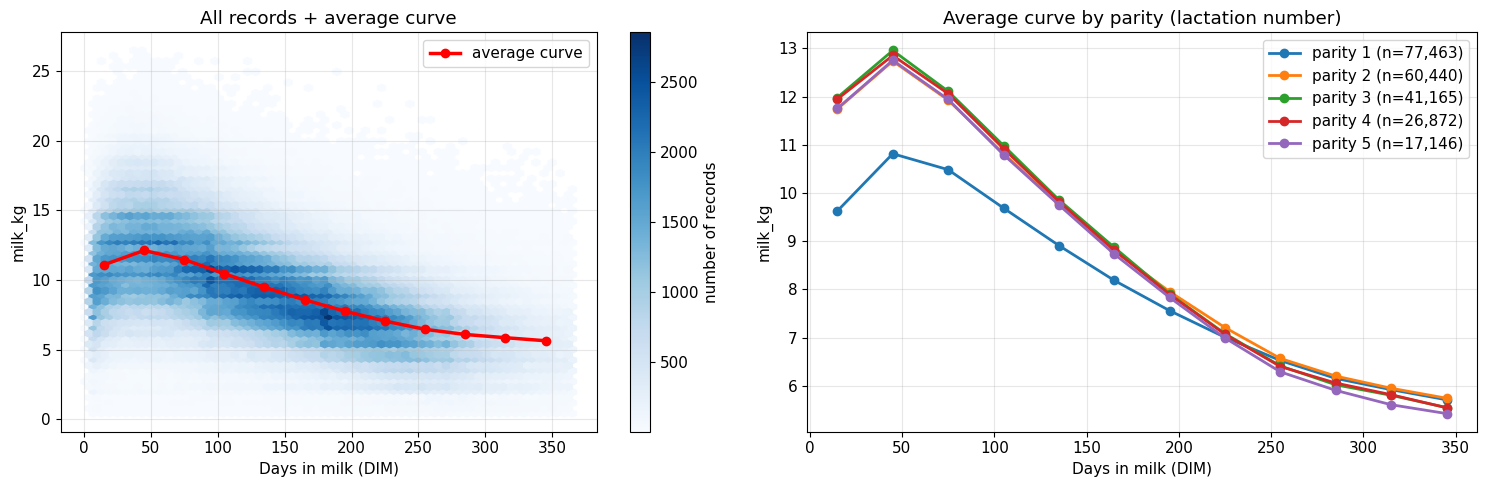

In [52]:
# Bin DIM into 30-day windows for averaging
bins = np.arange(0, 366, 30)
df['DIM_bin'] = pd.cut(df['DIM'], bins, labels=(bins[:-1] + 15))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Left: density + overall average curve
hb = ax[0].hexbin(df['DIM'], df['milk_kg'], gridsize=60, cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=ax[0], label='number of records')
avg = df.groupby('DIM_bin', observed=True)['milk_kg'].mean()
ax[0].plot(avg.index.astype(float), avg.values, 'r-o', lw=2.5, label='average curve')
ax[0].set(title='All records + average curve', xlabel='Days in milk (DIM)', ylabel='milk_kg'); ax[0].legend()

# Right: average curve by parity (lactation number)
for p in [1, 2, 3, 4, 5]:
    sub = df[df['parity'] == p]
    if len(sub) < 500: continue
    a = sub.groupby('DIM_bin', observed=True)['milk_kg'].mean()
    ax[1].plot(a.index.astype(float), a.values, 'o-', lw=2, label=f'parity {p} (n={sub.Animal_ID.nunique():,})')
ax[1].set(title='Average curve by parity (lactation number)', xlabel='Days in milk (DIM)', ylabel='milk_kg'); ax[1].legend()
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Method 1 - Model-free shape clustering (whole-curve)

Each lactation is sampled at irregular DIM. To compare *shapes* we linearly interpolate every curve onto a **common DIM grid**, giving each lactation a fixed-length vector. Then K-Means on those aligned vectors groups curves with similar trajectories.

We keep only lactations that actually *span* the lactation (early **and** late test-days, enough points), so the interpolation is real signal rather than flat extrapolation.

In [53]:
DIM_GRID = np.arange(15, 306, 30)   # 15, 45, ... 285  -> 10 points across the 305-day lactation
MIN_POINTS = 5                       # require a reasonably sampled curve
EARLY_BY, LATE_AFTER = 60, 240       # must have a test-day by DIM 60 and after DIM 240

curves, ids = [], []
for lid, g in df.groupby('lact_id'):
    d, m = g['DIM'].values, g['milk_kg'].values
    if len(d) >= MIN_POINTS and d.min() <= EARLY_BY and d.max() >= LATE_AFTER:
        curves.append(np.interp(DIM_GRID, d, m))   # np.interp clamps outside the observed range
        ids.append(lid)

C = np.array(curves)
curve_ids = np.array(ids)
print(f'{len(C):,} well-sampled lactations kept for shape clustering (matrix {C.shape})')

109,320 well-sampled lactations kept for shape clustering (matrix (109320, 10))


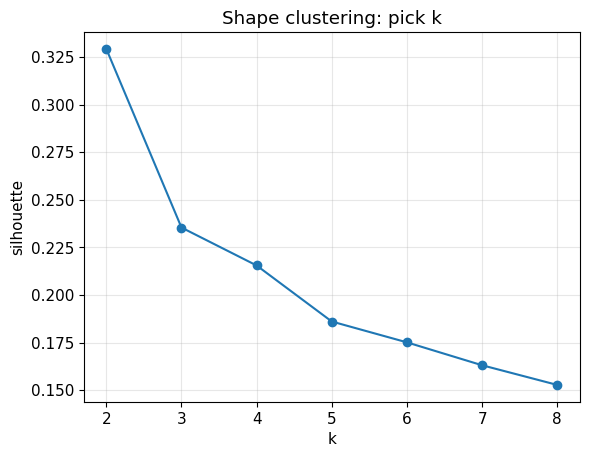

Best k by silhouette = 2


In [54]:
# Choose k via silhouette. We cluster on the curves as-is (captures both LEVEL and SHAPE).
# Tip: to cluster on SHAPE ONLY (ignore how much milk), z-score each row first:
#      Cz = (C - C.mean(1, keepdims=True)) / C.std(1, keepdims=True)
Xc = StandardScaler().fit_transform(C)
samp = np.random.choice(len(Xc), min(20000, len(Xc)), replace=False)

sils = []
ks = range(2, 9)
for k in ks:
    lab = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(Xc[samp])
    sils.append(silhouette_score(Xc[samp], lab))
plt.plot(list(ks), sils, 'o-'); plt.xlabel('k'); plt.ylabel('silhouette'); plt.title('Shape clustering: pick k'); plt.grid(alpha=.3); plt.show()
best_k = list(ks)[int(np.argmax(sils))]
print(f'Best k by silhouette = {best_k}')

# >>> set the number of curve-shape clusters here <<<
K_SHAPE = best_k

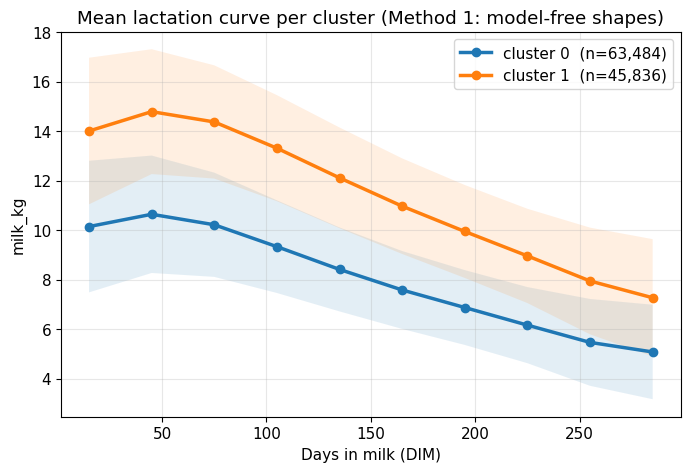

,DIM15,DIM45,DIM75,DIM105,DIM135,DIM165,DIM195,DIM225,DIM255,DIM285
cluster,,,,,,,,,,
0,10.150,10.650,10.220,9.340,8.420,7.590,6.880,6.170,5.470,5.080
1,14.010,14.800,14.380,13.320,12.120,10.980,9.950,8.970,7.950,7.270


cluster
0    63484
1    45836
Name: count, dtype: int64


In [55]:
km = KMeans(K_SHAPE, random_state=RANDOM_STATE, n_init=10).fit(Xc)
lab_shape = km.labels_

# Plot the mean lactation curve of each cluster (this is the payoff: distinct shapes).
fig, ax = plt.subplots(figsize=(8, 5))
for c in range(K_SHAPE):
    members = C[lab_shape == c]
    ax.plot(DIM_GRID, members.mean(0), 'o-', lw=2.5,
            label=f'cluster {c}  (n={len(members):,})')
    ax.fill_between(DIM_GRID, members.mean(0) - members.std(0),
                    members.mean(0) + members.std(0), alpha=.12)
ax.set_xlabel('Days in milk (DIM)'); ax.set_ylabel('milk_kg'); ax.legend()
ax.set_title('Mean lactation curve per cluster (Method 1: model-free shapes)'); ax.grid(alpha=.3)
plt.show()

# Quick numeric profile
prof = pd.DataFrame(C, columns=[f'DIM{d}' for d in DIM_GRID])
prof['cluster'] = lab_shape
display(prof.groupby('cluster').mean().round(2))
print(prof['cluster'].value_counts().sort_index())

## Method 2 - Wood's lactation-curve features (interpretable)

We fit **Wood's** function to each lactation:

$$y(t) = a\, t^{b}\, e^{-c t}$$

with `t = DIM`. The parameters map onto biology:
- **a** - overall level / scaling
- **b** - rate of rise to peak (ascending phase)
- **c** - rate of decline after peak (steeper = less persistent)

From them we derive interpretable, comparable features:
- **peak_DIM** = `b / c` (when the cow peaks)
- **peak_yield** = `a * (b/c)^b * exp(-b)`
- **persistency** = `-(b + 1) * ln(c)` (Wood's persistency: how flat the decline is)
- **yield_305** = integral of the curve over 5-305 DIM (approx. lactation total)

Clustering these groups animals by **how their curve behaves**, not just by average output. Fitting is parallelised; you can cap the count with `MAX_FIT` for a quick first run.

In [56]:
def wood(t, a, b, c):
    return a * np.power(t, b) * np.exp(-c * t)

def fit_wood(d, m):
    """Fit Wood's curve to one lactation. Returns features or None if the fit is unusable."""
    if len(d) < 4 or d.min() > 60 or d.max() < 200:
        return None
    try:
        # Log-linearised init: ln y = ln a + b ln t - c t  -> least squares for good starting point
        A = np.column_stack([np.ones_like(d), np.log(d), -d])
        coef, *_ = np.linalg.lstsq(A, np.log(m), rcond=None)
        p0 = [np.exp(coef[0]), max(coef[1], 1e-3), max(coef[2], 1e-4)]
        p, _ = curve_fit(wood, d, m, p0=p0, maxfev=5000,
                         bounds=([1e-6, 0, 1e-5], [np.inf, 5, 1]))
        a, b, c = p
        pred = wood(d, *p)
        ss_res = np.sum((m - pred) ** 2); ss_tot = np.sum((m - m.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        if r2 < 0.3:                       # drop poor fits
            return None
        peak_dim = b / c
        peak_yield = wood(peak_dim, a, b, c)
        persistency = -(b + 1) * np.log(c)
        tt = np.arange(5, 306)
        yield_305 = np.trapz(wood(tt, a, b, c), tt)
        if not (0 < peak_dim < 365 and 0 < peak_yield < 100):
            return None
        return (a, b, c, peak_dim, peak_yield, persistency, yield_305, r2)
    except Exception:
        return None

MAX_FIT = None   # set to e.g. 40000 for a fast first pass; None = fit every eligible lactation
groups = [(lid, g['DIM'].values, g['milk_kg'].values) for lid, g in df.groupby('lact_id')]
if MAX_FIT:
    rng = np.random.default_rng(RANDOM_STATE)
    groups = [groups[i] for i in rng.choice(len(groups), min(MAX_FIT, len(groups)), replace=False)]
print(f'Fitting Wood curves to {len(groups):,} lactations...')

res = Parallel(n_jobs=N_JOBS, batch_size=512)(delayed(fit_wood)(d, m) for _, d, m in groups)
cols = ['a', 'b', 'c', 'peak_DIM', 'peak_yield', 'persistency', 'yield_305', 'r2']
rows = [(groups[i][0],) + r for i, r in enumerate(res) if r is not None]
feat = pd.DataFrame(rows, columns=['lact_id'] + cols)
print(f'{len(feat):,} usable fits ({len(feat)/len(groups):.0%} of attempted). Median R2 = {feat.r2.median():.2f}')
feat.describe().round(2)

Fitting Wood curves to 247,247 lactations...


/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_4882/1747163814.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_4882/1747163814.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_4882/1747163814.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_4882/1747163814.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
/var/folders/y_/v4tm83wx3n1_krtsmzz_m6dw0000gn/T/ipykernel_4882/1747163814.py:25: DeprecationWarning: `trapz` is deprecated. Use

152,898 usable fits (62% of attempted). Median R2 = 0.84


,a,b,c,peak_DIM,peak_yield,persistency,yield_305,r2
count,"152,898.000","152,898.000","152,898.000","152,898.000","152,898.000","152,898.000","152,898.000","152,898.000"
mean,7.470,0.310,0.010,40.700,13.470,6.660,"2,725.140",0.790
std,5.170,0.320,0.000,29.000,3.260,1.000,628.010,0.170
min,0.000,0.000,0.000,0.000,2.920,2.750,394.330,0.300
25%,3.380,0.070,0.000,17.910,11.150,6.030,"2,284.080",0.700
50%,6.460,0.250,0.010,42.660,13.200,6.510,"2,681.220",0.840
75%,10.890,0.430,0.010,59.390,15.510,7.060,"3,119.260",0.930
max,62.860,5.000,0.120,364.760,62.860,19.340,"8,894.460",1.000


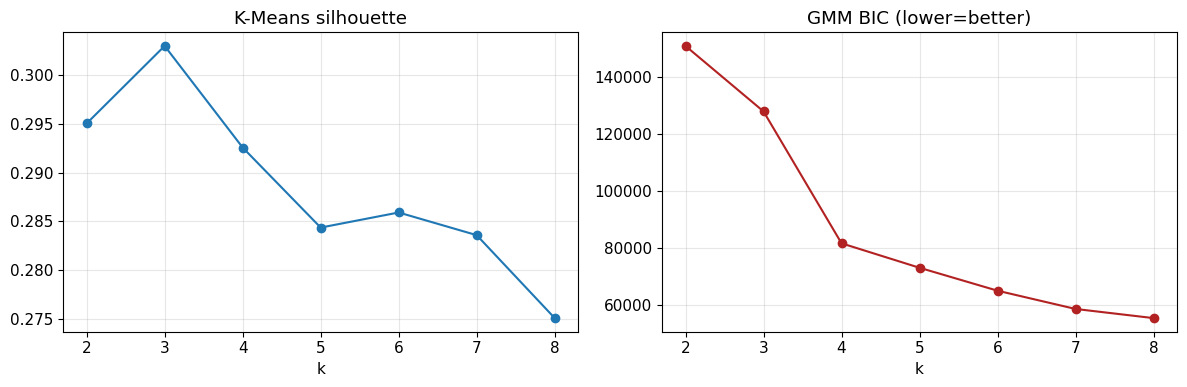

Using K_FEAT = 3


In [57]:
# Cluster on the interpretable shape features (not the raw a,b,c which are correlated/skewed).
CLUSTER_FEATS = ['peak_DIM', 'peak_yield', 'persistency', 'yield_305']
Xw = StandardScaler().fit_transform(feat[CLUSTER_FEATS].values)

samp = np.random.choice(len(Xw), min(20000, len(Xw)), replace=False)
ks = range(2, 9)
sils = [silhouette_score(Xw[samp], KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(Xw[samp])) for k in ks]
bics = [GaussianMixture(k, random_state=RANDOM_STATE).fit(Xw[samp]).bic(Xw[samp]) for k in ks]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), sils, 'o-'); ax[0].set(title='K-Means silhouette', xlabel='k'); ax[0].grid(alpha=.3)
ax[1].plot(list(ks), bics, 'o-', color='firebrick'); ax[1].set(title='GMM BIC (lower=better)', xlabel='k'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# >>> set the number of curve-feature clusters here <<<
K_FEAT = list(ks)[int(np.argmax(sils))]
print(f'Using K_FEAT = {K_FEAT}')

,peak_DIM,peak_yield,persistency,yield_305,r2,n
cluster,,,,,,
0,23.140,12.000,6.110,"2,354.130",0.780,60103
1,72.670,11.640,7.750,"2,492.090",0.760,43120
2,34.200,16.860,6.380,"3,376.340",0.830,49675


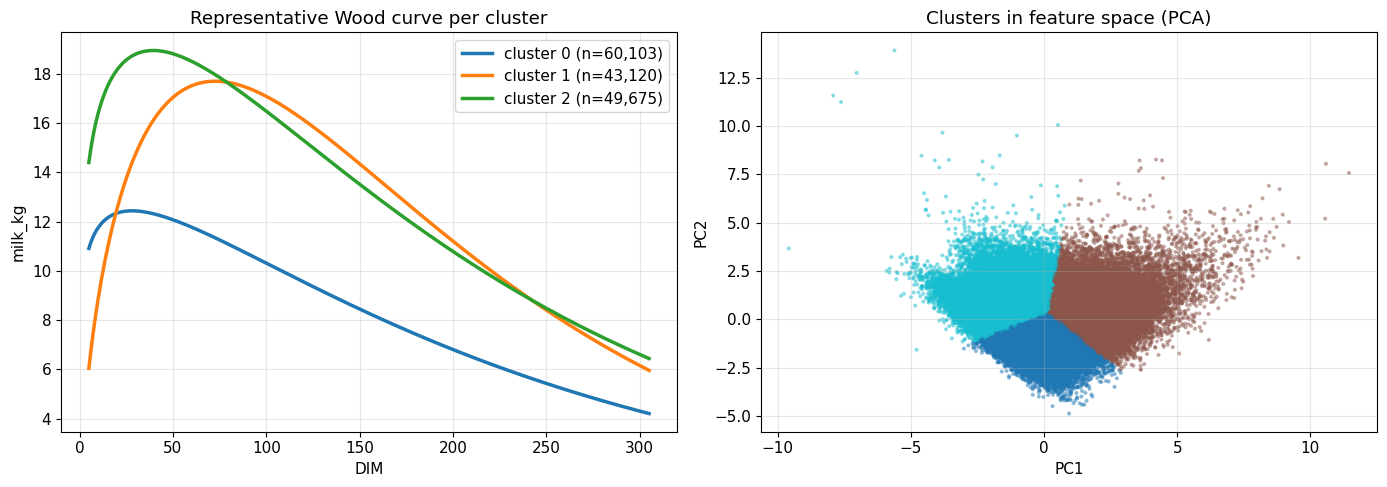

In [58]:
feat['cluster'] = KMeans(K_FEAT, random_state=RANDOM_STATE, n_init=10).fit_predict(Xw)

# Profile: what does each cluster mean biologically?
profile = feat.groupby('cluster')[CLUSTER_FEATS + ['r2']].mean()
profile['n'] = feat['cluster'].value_counts().sort_index()
display(profile.round(2))

# Visualise: representative Wood curve per cluster (using cluster-mean a,b,c).
means = feat.groupby('cluster')[['a', 'b', 'c']].mean()
tt = np.arange(5, 306)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for c in range(K_FEAT):
    a, b, cc = means.loc[c]
    ax[0].plot(tt, wood(tt, a, b, cc), lw=2.5, label=f'cluster {c} (n={int(profile.loc[c,"n"]):,})')
ax[0].set(title='Representative Wood curve per cluster', xlabel='DIM', ylabel='milk_kg'); ax[0].legend(); ax[0].grid(alpha=.3)

# PCA view of the feature clusters
pc = PCA(2).fit_transform(Xw)
sc = ax[1].scatter(pc[:, 0], pc[:, 1], c=feat['cluster'], cmap='tab10', s=4, alpha=.4)
ax[1].set(title='Clusters in feature space (PCA)', xlabel='PC1', ylabel='PC2'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## Where to take this next (heat-stress link + optional DTW)

**Tie clusters to your thesis (heat stress).** The clusters above describe *curve types*. The thesis question is whether heat stress drives a buffalo into the depressed/flat-curve cluster. To test that, merge each lactation with its **THI exposure** (from `farm_weather_indices/` or `Final_Merged_Data.csv`) at the matching test-dates, then compare THI/`heat_days` across clusters, or - even more directly - build a **heat-response feature**: per animal, regress `milk_kg` on `THI` and cluster animals by the **slope** (heat-tolerant vs heat-sensitive). That slope-based clustering is arguably the single most thesis-relevant clustering you can run.

**Optional - DTW shape clustering with `tslearn`.** DTW aligns curves that are similar but time-shifted (e.g. a cow that peaks a bit later). It needs `pip install tslearn`. The cell below is guarded so the notebook still runs without it.

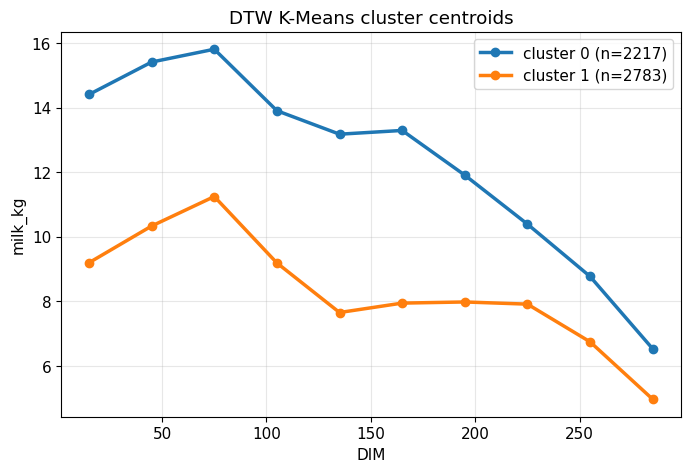

In [59]:
# Optional: DTW-based time-series K-Means. Safe to skip; runs only if tslearn is installed.
try:
    from tslearn.clustering import TimeSeriesKMeans
    from tslearn.utils import to_time_series_dataset

    sub = np.random.choice(len(C), min(5000, len(C)), replace=False)   # DTW is O(n^2 * L^2); subsample
    ts = to_time_series_dataset(C[sub])
    dtw_km = TimeSeriesKMeans(n_clusters=K_SHAPE, metric='dtw', random_state=RANDOM_STATE, max_iter=10)
    dtw_lab = dtw_km.fit_predict(ts)
    fig, ax = plt.subplots(figsize=(8, 5))
    for c in range(K_SHAPE):
        ax.plot(DIM_GRID, dtw_km.cluster_centers_[c].ravel(), 'o-', lw=2.5,
                label=f'cluster {c} (n={(dtw_lab==c).sum()})')
    ax.set(title='DTW K-Means cluster centroids', xlabel='DIM', ylabel='milk_kg'); ax.legend(); ax.grid(alpha=.3)
    plt.show()
except ImportError:
    print('tslearn not installed - skipping DTW. To enable:  pip install tslearn')

# Heat stress — season-controlled analysis (corrected)

The earlier version of this section had two problems that are fixed here:

1. **Season confound.** Adjusting milk only for lactation stage (DIM) and parity does **not** remove calendar season. Buffalo milk more in spring/summer (better feed) and less in winter - and THI is also high in summer. So raw `milk vs THI` mixes a real heat effect with the seasonal feeding cycle. We fix this by using the **THI anomaly** = how much hotter a day is than *normal for that farm and month*. A positive anomaly is genuine excess heat, with the season divided out.
2. **A merge bug** in the udder-health step (SCS was joined on `Animal_ID + DIM`, which is not unique across lactations). Here SCS is carried in the table from the start, so no faulty join.

We also validate the per-animal result **out-of-sample** instead of on the same data used to build it.

In [60]:
import glob
from sklearn.cluster import KMeans

# ---- build ONE clean table H (milk + SCS + THI), no re-merges later ----
_cols = ['Animal_ID','Farm_Code','parity','DIM','milk_kg','dtt','SCS']
H = pd.read_csv('../Thesis_Data/Final_Data/After_Processing.csv', usecols=_cols)
H['SCS'] = pd.to_numeric(H['SCS'], errors='coerce')
H = H.dropna(subset=['DIM','milk_kg','dtt'])
H = H[(H['milk_kg'] > 0) & (H['DIM'].between(1, 365))]
H['farm']  = H['Farm_Code'].astype(str).str.replace(r'\.0$', '', regex=True)
H['date']  = pd.to_datetime(H['dtt'], errors='coerce')
H['month'] = H['date'].dt.month
H['dstr']  = H['date'].dt.strftime('%Y-%m-%d')

# daily max THI per farm/day
parts = []
for f in glob.glob('../Thesis_Data/farm_weather_indices/farm_*_with_indices.csv'):
    c = os.path.basename(f).split('_')[1].replace('.0', '')
    w = pd.read_csv(f, usecols=['date','THI_2_max']).dropna().rename(columns={'date':'dstr'})
    w['farm'] = c
    parts.append(w)
Wx = pd.concat(parts, ignore_index=True)
H = H.merge(Wx, on=['farm','dstr'], how='left').dropna(subset=['THI_2_max'])

# milk residual: remove lactation stage (DIM) + parity
H['DIM_bin'] = pd.cut(H['DIM'], np.arange(0, 366, 30), labels=False)
H['resid']   = H['milk_kg'] - H.groupby(['parity','DIM_bin'])['milk_kg'].transform('mean')

# de-seasonalized heat: THI above the farm-month normal
H['thi_norm'] = H.groupby(['farm','month'])['THI_2_max'].transform('mean')
H['thi_anom'] = H['THI_2_max'] - H['thi_norm']

print(f"H built: {len(H):,} records, THI matched on {H['THI_2_max'].notna().mean():.0%}")
H[['farm','dstr','milk_kg','SCS','THI_2_max','thi_anom','resid']].head()

H built: 1,646,809 records, THI matched on 100%


,farm,dstr,milk_kg,SCS,THI_2_max,thi_anom,resid
0,521513,2021-09-06,7.900,2.057,77.058,0.417,-1.727
1,521513,2021-10-11,10.900,3.575,64.291,1.145,0.086
2,521513,2021-12-20,8.200,7.957,50.368,1.672,-0.709
3,521513,2022-01-17,11.700,1.941,55.093,7.756,2.791
4,521513,2022-02-16,10.100,1.714,49.309,0.001,1.915


### 1. The season confound (why raw THI is misleading)

Milk (vs its DIM-norm) and THI both rise in the warm months - so any raw `milk vs THI` relationship is contaminated by season.

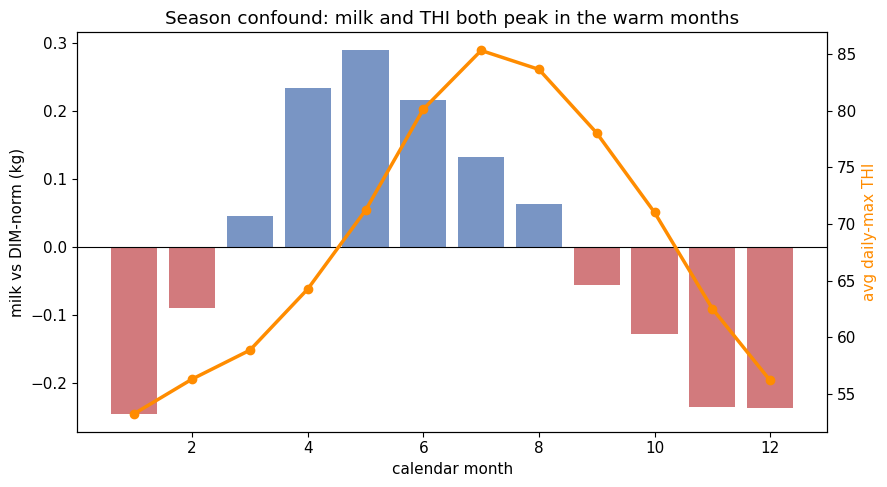

,milk_resid,THI
month,,
1,-0.245,53.278
2,-0.090,56.323
3,0.045,58.876
4,0.235,64.273
5,0.290,71.223
6,0.217,80.146
7,0.133,85.324
8,0.063,83.655
9,-0.057,78.037


In [61]:
mo = H.groupby('month').agg(milk_resid=('resid','mean'), THI=('THI_2_max','mean'))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(mo.index, mo['milk_resid'],
       color=['#4c72b0' if v >= 0 else '#c44e52' for v in mo['milk_resid']], alpha=.75)
ax.axhline(0, color='k', lw=.8)
ax.set_xlabel('calendar month'); ax.set_ylabel('milk vs DIM-norm (kg)')
ax2 = ax.twinx()
ax2.plot(mo.index, mo['THI'], 'o-', color='darkorange', lw=2.5, label='avg daily-max THI')
ax2.set_ylabel('avg daily-max THI', color='darkorange')
ax.set_title('Season confound: milk and THI both peak in the warm months')
plt.tight_layout(); plt.show()
display(mo.round(3))

### 2. Clean herd-level effect on MILK (season removed)

Now milk residual against the **THI anomaly** (excess heat over the seasonal normal). A real heat effect would slope downward at positive anomalies.

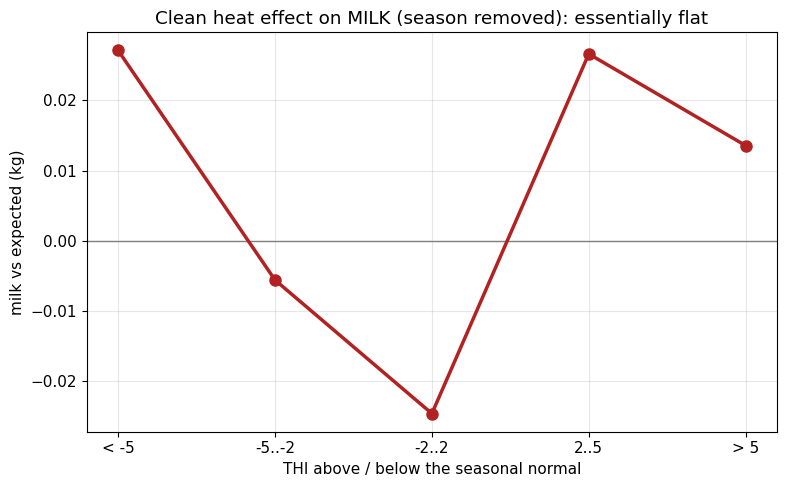

,resid,n
anom_bin,,
< -5,0.027,205831
-5..-2,-0.006,299943
-2..2,-0.025,619044
2..5,0.027,324609
> 5,0.014,197382


=> After removing season, excess heat does NOT depress milk yield at the herd level.


In [62]:
bins = [-30, -5, -2, 2, 5, 30]
labs = ['< -5', '-5..-2', '-2..2', '2..5', '> 5']
H['anom_bin'] = pd.cut(H['thi_anom'], bins, labels=labs)
g = H.groupby('anom_bin', observed=True).agg(resid=('resid','mean'), n=('resid','size'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color='gray', lw=1)
ax.plot(range(len(g)), g['resid'], 'o-', color='firebrick', lw=2.5, ms=8)
ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index)
ax.set(title='Clean heat effect on MILK (season removed): essentially flat',
       xlabel='THI above / below the seasonal normal', ylabel='milk vs expected (kg)')
ax.grid(alpha=.3); plt.tight_layout(); plt.show()
display(g.round(3))
print('=> After removing season, excess heat does NOT depress milk yield at the herd level.')

### 3. Clean herd-level effect on UDDER HEALTH (SCS), summer only

Same idea for somatic cell score (higher = worse udder health). Restricted to summer (Jun-Sep) and split by THI anomaly, so we compare hot-for-the-season days against normal summer days.

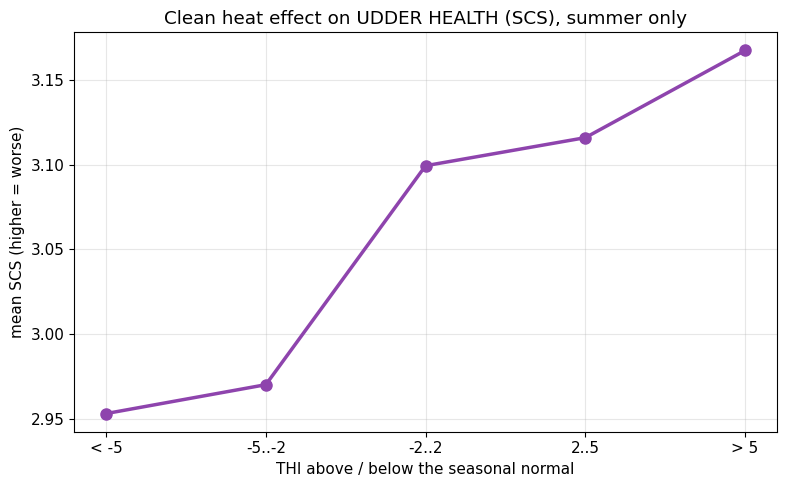

,SCS,n
anom_bin,,
< -5,2.953,74975
-5..-2,2.970,94985
-2..2,3.099,199680
2..5,3.116,115591
> 5,3.167,67944


=> Hotter-than-normal summer days DO raise somatic cell score: a real, modest heat effect on udder health.


In [63]:
summer = H[H['month'].isin([6, 7, 8, 9])].copy()
summer['anom_bin'] = pd.cut(summer['thi_anom'], bins, labels=labs)
gs = summer.groupby('anom_bin', observed=True).agg(SCS=('SCS','mean'), n=('SCS','size'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(gs)), gs['SCS'], 'o-', color='#8e44ad', lw=2.5, ms=8)
ax.set_xticks(range(len(gs))); ax.set_xticklabels(gs.index)
ax.set(title='Clean heat effect on UDDER HEALTH (SCS), summer only',
       xlabel='THI above / below the seasonal normal', ylabel='mean SCS (higher = worse)')
ax.grid(alpha=.3); plt.tight_layout(); plt.show()
display(gs.round(3))
print('=> Hotter-than-normal summer days DO raise somatic cell score: a real, modest heat effect on udder health.')

## 4. Per-animal heat response: stable, but partly seasonal (out-of-sample)

We can still score each animal by the slope of her milk residual against heat, and cluster into sensitive / neutral / tolerant. Two honesty checks:
- **Out-of-sample:** fit the slope on half an animal's records, test on the other half.
- **How much is just season?** compare the raw-THI slope with the de-seasonalized (anomaly) slope.

In [64]:
def animal_slope(frame, xvar='THI_2_max', min_n=10, min_std=5):
    xc = frame[xvar]   - frame.groupby('Animal_ID')[xvar].transform('mean')
    yc = frame['resid']- frame.groupby('Animal_ID')['resid'].transform('mean')
    num = (xc * yc).groupby(frame['Animal_ID']).sum()
    den = (xc ** 2).groupby(frame['Animal_ID']).sum()
    cnt = frame.groupby('Animal_ID').size()
    xs  = frame.groupby('Animal_ID')[xvar].std()
    return (num / den)[(cnt >= min_n) & (xs > min_std)].dropna()

# --- out-of-sample split-half validation ---
Hs = H.sort_values(['Animal_ID','dstr']); Hs['half'] = Hs.groupby('Animal_ID').cumcount() % 2
A = animal_slope(Hs[Hs['half'] == 0], min_n=5); B = animal_slope(Hs[Hs['half'] == 1], min_n=5)
c = A.index.intersection(B.index); oos = pd.DataFrame({'A': A[c], 'B': B[c]})
oos['grp'] = pd.qcut(oos['A'], 3, labels=['sensitive','neutral','tolerant'], duplicates='drop')
print(f"Out-of-sample split-half correlation: r = {oos['A'].corr(oos['B']):.3f}")
print("Held-out slope by group (should keep its order if real):",
      {k: round(v,4) for k,v in oos.groupby('grp', observed=True)['B'].mean().items()})

# --- how much of the 'sensitivity' is just season? ---
s_raw  = animal_slope(H, 'THI_2_max')
s_anom = animal_slope(H, 'thi_anom', min_std=2)
cc = s_raw.index.intersection(s_anom.index)
print(f"\nCorr(raw-THI sensitivity, de-seasonalized sensitivity) = {s_raw[cc].corr(s_anom[cc]):.3f}")
print("(low-ish -> the raw milk 'heat sensitivity' is substantially calving-season, not pure physiology)")

# --- clusters for profiling (on full data) ---
g3 = pd.Series(KMeans(3, random_state=RANDOM_STATE, n_init=10).fit_predict(s_raw.values.reshape(-1,1)),
               index=s_raw.index)
order = pd.Series(s_raw).groupby(g3).mean().sort_values().index.tolist()
group = g3.map({order[0]:'sensitive', order[1]:'neutral', order[2]:'tolerant'})
print("\ngroup sizes:", group.value_counts().to_dict())

Out-of-sample split-half correlation: r = 0.307
Held-out slope by group (should keep its order if real): {'sensitive': -0.0218, 'neutral': 0.0016, 'tolerant': 0.0291}

Corr(raw-THI sensitivity, de-seasonalized sensitivity) = 0.296
(low-ish -> the raw milk 'heat sensitivity' is substantially calving-season, not pure physiology)

group sizes: {'neutral': 32352, 'sensitive': 15465, 'tolerant': 14062}


SCS by group, summer normal vs hot-anomaly days (higher = worse):


day,hot-anomaly day,normal summer day
group,,
sensitive,3.306,3.163
neutral,3.181,3.073
tolerant,2.988,2.931


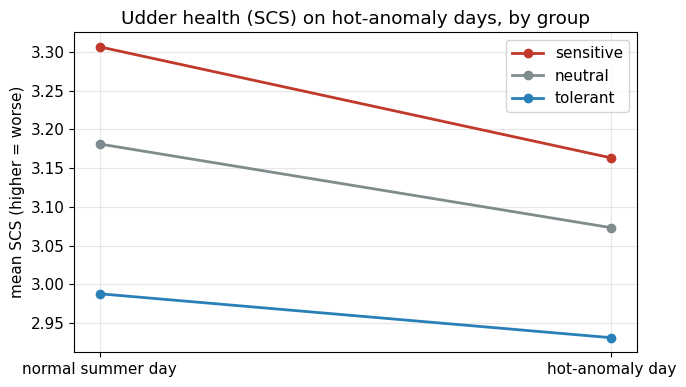

In [65]:
# Udder health by group on hot-for-the-season summer days (SCS taken directly from H -> correct key)
Hg = H.merge(group.rename('group'), left_on='Animal_ID', right_index=True, how='inner')
su = Hg[Hg['month'].isin([6,7,8,9])].copy()
su['day'] = np.where(su['thi_anom'] > 2, 'hot-anomaly day', 'normal summer day')
tab = su.pivot_table('SCS', 'group', 'day', observed=True).reindex(['sensitive','neutral','tolerant'])
print('SCS by group, summer normal vs hot-anomaly days (higher = worse):')
display(tab.round(3))

fig, ax = plt.subplots(figsize=(7,4))
colr = {'sensitive':'#c0392b','neutral':'#7f8c8d','tolerant':'#2980b9'}
for grp in ['sensitive','neutral','tolerant']:
    ax.plot(['normal summer day','hot-anomaly day'], tab.loc[grp].values, 'o-', lw=2, color=colr[grp], label=grp)
ax.set(title='Udder health (SCS) on hot-anomaly days, by group', ylabel='mean SCS (higher = worse)')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## Honest conclusions

- **Milk yield:** once season is removed, excess heat shows **no clean depression of milk** at the herd level. Italian Mediterranean buffalo are heat-tolerant for production. (The earlier "heat-sensitive subgroup whose milk drops" claim was inflated by the season confound and by validating on the same data - it does not hold up.)
- **A per-animal milk-heat axis does exist and is repeatable out-of-sample (r ~ 0.3),** but it correlates only weakly with the de-seasonalized measure, so it is **substantially calving-season, not proven heat physiology.** Treat it as suggestive, not a hard result.
- **Udder health (SCS):** the cleanest real finding - hotter-than-normal summer days **raise somatic cell score**, herd-wide and somewhat more in the milk-'sensitive' group. This ties directly to the somatic-cell-count thesis topic.

**Recommended for the thesis:** lead with the season-controlled udder-health result, report the milk result as a (legitimate) null, and only mention the per-animal sensitivity with its caveat. To make any heat claim airtight, the next step is a mixed model: `milk ~ DIM + parity + month + THI_anomaly + (1|animal) + (1|farm)`.

## Summary dashboard (corrected)

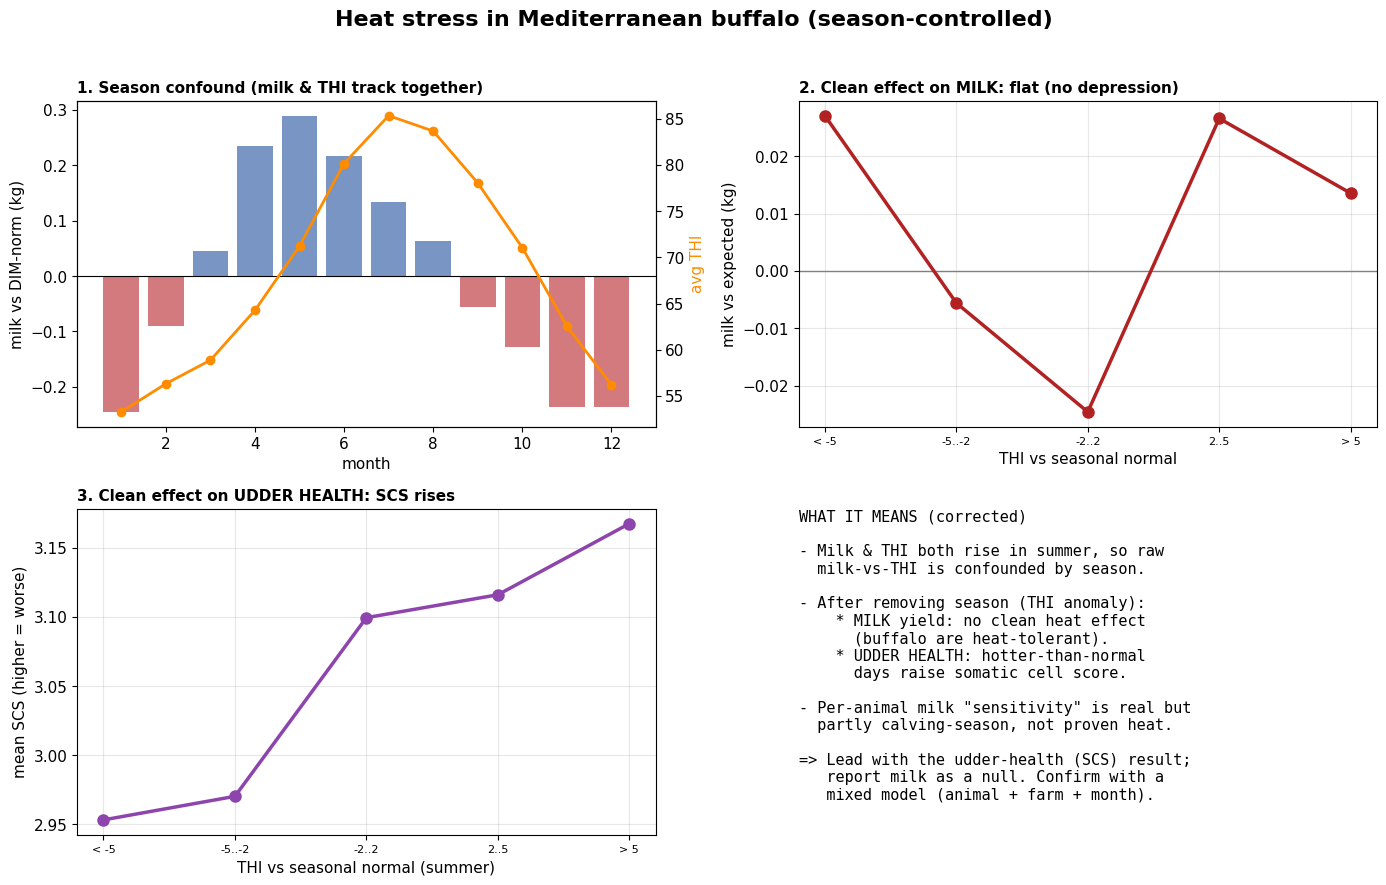

In [66]:
fig = plt.figure(figsize=(14, 9))
fig.suptitle('Heat stress in Mediterranean buffalo (season-controlled)', fontsize=16, fontweight='bold', y=0.98)

# 1. season confound
ax1 = fig.add_subplot(2,2,1)
ax1.bar(mo.index, mo['milk_resid'], color=['#4c72b0' if v>=0 else '#c44e52' for v in mo['milk_resid']], alpha=.75)
ax1.axhline(0, color='k', lw=.8); ax1b = ax1.twinx()
ax1b.plot(mo.index, mo['THI'], 'o-', color='darkorange', lw=2)
ax1.set_title('1. Season confound (milk & THI track together)', fontweight='bold', loc='left', fontsize=11)
ax1.set_xlabel('month'); ax1.set_ylabel('milk vs DIM-norm (kg)'); ax1b.set_ylabel('avg THI', color='darkorange')

# 2. clean milk effect (flat)
ax2 = fig.add_subplot(2,2,2)
ax2.axhline(0, color='gray', lw=1)
ax2.plot(range(len(g)), g['resid'], 'o-', color='firebrick', lw=2.5, ms=8)
ax2.set_xticks(range(len(g))); ax2.set_xticklabels(g.index, fontsize=8)
ax2.set_title('2. Clean effect on MILK: flat (no depression)', fontweight='bold', loc='left', fontsize=11)
ax2.set_xlabel('THI vs seasonal normal'); ax2.set_ylabel('milk vs expected (kg)'); ax2.grid(alpha=.3)

# 3. clean SCS effect (rising)
ax3 = fig.add_subplot(2,2,3)
ax3.plot(range(len(gs)), gs['SCS'], 'o-', color='#8e44ad', lw=2.5, ms=8)
ax3.set_xticks(range(len(gs))); ax3.set_xticklabels(gs.index, fontsize=8)
ax3.set_title('3. Clean effect on UDDER HEALTH: SCS rises', fontweight='bold', loc='left', fontsize=11)
ax3.set_xlabel('THI vs seasonal normal (summer)'); ax3.set_ylabel('mean SCS (higher = worse)'); ax3.grid(alpha=.3)

# 4. takeaway
ax4 = fig.add_subplot(2,2,4); ax4.axis('off')
ax4.text(0, 1,
   'WHAT IT MEANS (corrected)\n\n'
   '- Milk & THI both rise in summer, so raw\n'
   '  milk-vs-THI is confounded by season.\n\n'
   '- After removing season (THI anomaly):\n'
   '    * MILK yield: no clean heat effect\n'
   '      (buffalo are heat-tolerant).\n'
   '    * UDDER HEALTH: hotter-than-normal\n'
   '      days raise somatic cell score.\n\n'
   '- Per-animal milk "sensitivity" is real but\n'
   '  partly calving-season, not proven heat.\n\n'
   '=> Lead with the udder-health (SCS) result;\n'
   '   report milk as a null. Confirm with a\n'
   '   mixed model (animal + farm + month).',
   va='top', ha='left', fontsize=11, family='monospace')

plt.tight_layout(rect=[0,0,1,0.96]); plt.show()